# 🌋 Klasifikasi Tingkat Kerentanan Seismik Sesar Lembang
## Berbasis Algoritma Support Vector Machine (SVM)

**Nama:** Dava Ihza Bagus Setyawan  
**NIM:** 1202220313  
**Program Studi:** S1 Sistem Informasi — Universitas Telkom  

---
### 📋 Alur Pipeline Penelitian
```
FASE 1: Setup & Import Library
    ↓
FASE 2: Load & Eksplorasi Data (EDA)
    ↓
FASE 3: Preprocessing Data
    ├── Pembersihan Data
    ├── Filtering Wilayah Sesar Lembang
    ├── Pelabelan Kelas Risiko (Rendah/Sedang/Tinggi)
    └── Normalisasi Min-Max Scaling
    ↓
FASE 4: Pembagian Data (80:20)
    ↓
FASE 5: Training Model SVM (Kernel RBF)
    ↓
FASE 6: Evaluasi (Confusion Matrix, Accuracy, Precision, Recall, F1)
    ↓
FASE 7: K-Fold Cross Validation
    ↓
FASE 8: Hyperparameter Tuning (C & Gamma)
    ↓
FASE 9: Visualisasi Hasil & Peta Risiko
```

---
## ⚙️ FASE 1 — Setup & Import Library

In [ ]:
# Install library tambahan jika diperlukan
!pip install scikit-learn pandas numpy matplotlib seaborn plotly folium -q

# ── Import Library Utama ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: SVM & Preprocessing
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

# Scikit-learn: Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Visualisasi Tambahan
import plotly.express as px
import folium
from IPython.display import display

# Setting plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Semua library berhasil diimport!')
print(f'   Scikit-learn version: {__import__("sklearn").__version__}')
print(f'   Pandas version      : {pd.__version__}')
print(f'   NumPy version       : {np.__version__}')

✅ Semua library berhasil diimport!
   Scikit-learn version: 1.6.1
   Pandas version      : 2.2.2
   NumPy version       : 2.0.2


---
## 📂 FASE 2 — Load Data

> Upload semua file CSV hasil download dari USGS (2000–2004, 2005–2009, 2010–2014, 2015–2019, 2020–2026).
> Pilih semua file sekaligus saat dialog muncul — otomatis digabung jadi satu.

In [ ]:
# ── LOAD DATA — Upload CSV dari USGS ─────────────────────────────────────────
# Upload 5 file CSV yang sudah didownload dari USGS (2000-2004, 2005-2009, dll)
# Jalankan sel ini, klik 'Choose Files', pilih semua file sekaligus

from google.colab import files
from io import StringIO

print('📁 Upload semua file CSV gempa dari USGS (boleh pilih sekaligus)...')
uploaded = files.upload()

# Gabungkan semua file yang diupload jadi satu DataFrame
dfs_uploaded = []
for fname, content in uploaded.items():
    df_temp = pd.read_csv(StringIO(content.decode('utf-8')))
    print(f'  ✅ {fname}: {len(df_temp):,} baris')
    dfs_uploaded.append(df_temp)

df_raw = pd.concat(dfs_uploaded, ignore_index=True)
df_raw = df_raw.drop_duplicates(subset=['id'] if 'id' in df_raw.columns else None)
df_raw = df_raw.sort_values('time').reset_index(drop=True)

print(f'\n✅ Semua file berhasil digabungkan!')
print(f'   Total event  : {len(df_raw):,} baris')
print(f'   Kolom        : {list(df_raw.columns[:8])} ...')
print(f'   Periode data : {df_raw["time"].min()[:10]} s/d {df_raw["time"].max()[:10]}')

📁 Upload semua file CSV gempa dari USGS (boleh pilih sekaligus)...


Saving 1990–1994.csv to 1990–1994.csv
Saving 1995–1999.csv to 1995–1999.csv
Saving 2000–2004.csv to 2000–2004.csv
Saving 2005–2009.csv to 2005–2009.csv
Saving 2010–2014.csv to 2010–2014.csv
Saving 2015–2019.csv to 2015–2019.csv
Saving 2020–2026.csv to 2020–2026.csv
  ✅ 1990–1994.csv: 4,132 baris
  ✅ 1995–1999.csv: 7,364 baris
  ✅ 2000–2004.csv: 7,255 baris
  ✅ 2005–2009.csv: 13,358 baris
  ✅ 2010–2014.csv: 8,260 baris
  ✅ 2015–2019.csv: 10,290 baris
  ✅ 2020–2026.csv: 12,755 baris

✅ Semua file berhasil digabungkan!
   Total event  : 63,414 baris
   Kolom        : ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap'] ...
   Periode data : 1990-01-01 s/d 2026-04-22


### 🔍 Eksplorasi Data Awal (EDA)

In [ ]:
# Lihat struktur data
print('='*60)
print('INFO DATASET')
print('='*60)
print(f'Shape    : {df_raw.shape}')
print(f'Kolom    : {list(df_raw.columns)}')
print()
df_raw.head(10)

INFO DATASET
Shape    : (63414, 22)
Kolom    : ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']



,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,1990-01-01T14:10:03.050Z,-9.412,107.260,31.9,4.7,mb,NaN,NaN,NaN,1.1,...,2014-11-07T00:45:26.746Z,"245 km S of Banjar, Indonesia",earthquake,NaN,NaN,NaN,7.0,reviewed,us,us
1,1990-01-01T16:07:27.320Z,-7.183,125.242,527.1,5.3,mw,NaN,NaN,NaN,1.1,...,2025-12-19T21:02:55.332Z,"155 km N of Likisá, Timor Leste",earthquake,NaN,4.7,NaN,NaN,reviewed,us,hrv
2,1990-01-02T15:34:16.920Z,-2.849,128.687,33.0,4.7,mb,NaN,NaN,NaN,1.2,...,2014-11-07T00:45:27.535Z,"Ceram Sea, Indonesia",earthquake,NaN,NaN,NaN,8.0,reviewed,us,us
3,1990-01-02T21:38:18.610Z,-2.550,127.713,34.0,5.4,mw,NaN,NaN,NaN,1.2,...,2025-12-19T21:02:56.476Z,"137 km NNW of Ambon, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
4,1990-01-04T12:58:13.170Z,-3.906,131.545,33.0,4.3,mb,NaN,NaN,NaN,1.5,...,2014-11-07T00:45:28.416Z,"232 km NW of Tual, Indonesia",earthquake,NaN,NaN,NaN,3.0,reviewed,us,us
5,1990-01-05T10:10:21.810Z,-8.800,106.442,29.0,5.8,mw,NaN,NaN,NaN,1.3,...,2022-04-28T20:00:40.855Z,"200 km S of Pelabuhanratu, Indonesia",earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
6,1990-01-06T07:16:53.300Z,-6.734,133.843,33.0,4.3,mb,NaN,NaN,NaN,1.4,...,2014-11-07T00:45:29.110Z,"171 km SE of Tual, Indonesia",earthquake,NaN,NaN,NaN,2.0,reviewed,us,us
7,1990-01-07T05:31:52.930Z,1.406,126.473,88.9,4.7,mb,NaN,NaN,NaN,1.0,...,2014-11-07T00:45:29.791Z,"122 km NW of Ternate, Indonesia",earthquake,NaN,17.3,NaN,4.0,reviewed,us,us
8,1990-01-09T12:53:14.160Z,-0.732,133.320,33.0,4.2,mb,NaN,NaN,NaN,1.3,...,2014-11-07T00:45:30.707Z,"84 km W of Manokwari, Indonesia",earthquake,NaN,NaN,NaN,3.0,reviewed,us,us
9,1990-01-09T18:31:43.250Z,-10.040,123.932,33.0,3.9,mb,NaN,NaN,NaN,1.5,...,2014-11-07T00:45:30.939Z,"38 km ENE of Kupang, Indonesia",earthquake,NaN,NaN,NaN,2.0,reviewed,us,us


In [ ]:
# Statistik deskriptif
print('STATISTIK DESKRIPTIF')
df_raw[['mag', 'depth', 'latitude', 'longitude']].describe()

STATISTIK DESKRIPTIF


,mag,depth,latitude,longitude
count,63414.00000,63414.000000,63414.000000,63414.000000
mean,4.51586,82.994505,-2.459386,121.275083
std,0.44491,104.672367,4.568350,12.205487
min,2.70000,0.000000,-11.000000,-120.844833
25%,4.20000,30.000000,-6.760750,114.913250
50%,4.50000,35.305000,-2.619850,126.222000
75%,4.70000,102.000000,1.487000,128.775000
max,9.10000,675.500000,35.544667,140.999000


In [ ]:
# Cek missing values
print('MISSING VALUES:')
missing = df_raw.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal baris dengan missing: {df_raw.isnull().any(axis=1).sum():,}')

MISSING VALUES:
nst                30155
gap                15616
dmin               37252
rms                   36
horizontalError    39404
depthError         22721
magError           37401
magNst              4695
dtype: int64

Total baris dengan missing: 55,459


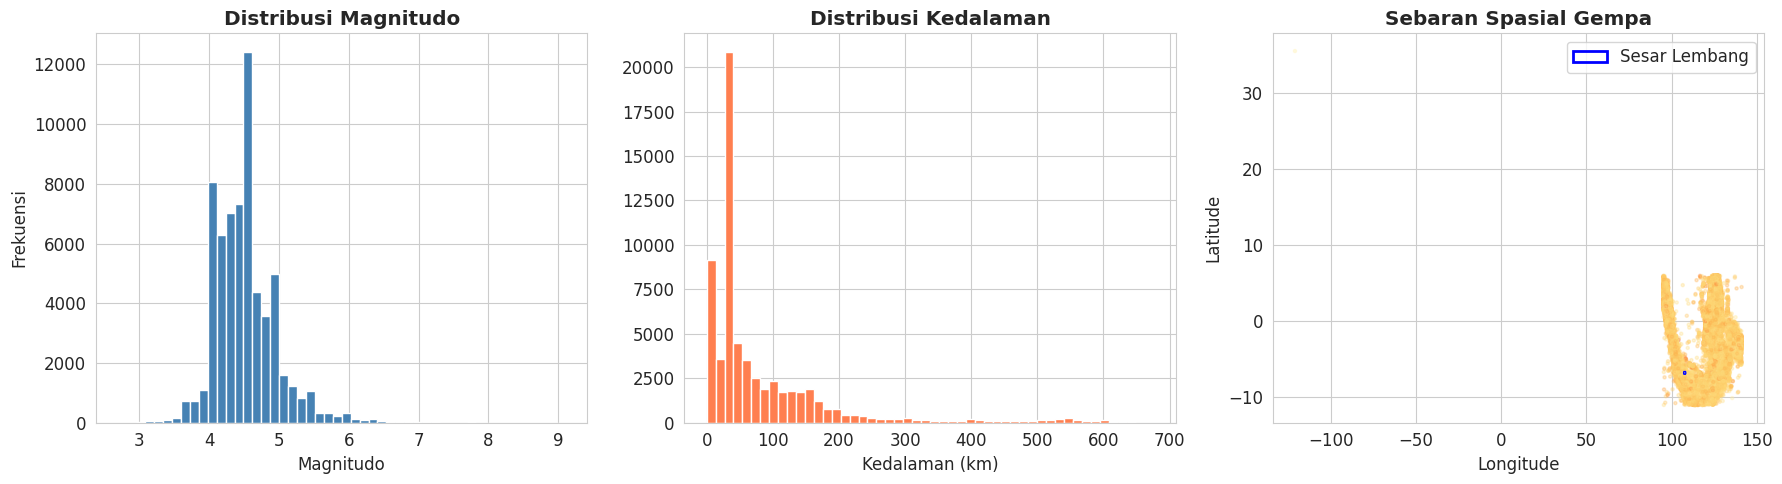

✅ Plot EDA tersimpan!


In [ ]:
# Distribusi Magnitudo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_raw['mag'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Magnitudo', fontweight='bold')
axes[0].set_xlabel('Magnitudo')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df_raw['depth'].dropna(), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribusi Kedalaman', fontweight='bold')
axes[1].set_xlabel('Kedalaman (km)')

axes[2].scatter(df_raw['longitude'], df_raw['latitude'],
                c=df_raw['mag'], cmap='YlOrRd', alpha=0.3, s=5)
axes[2].set_title('Sebaran Spasial Gempa', fontweight='bold')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
# Tandai area Sesar Lembang
import matplotlib.patches as mpatches
rect = mpatches.FancyBboxPatch((107.40, -6.85), 0.40, 0.15,
                                boxstyle='round,pad=0.01',
                                linewidth=2, edgecolor='blue',
                                facecolor='none', label='Sesar Lembang')
axes[2].add_patch(rect)
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot EDA tersimpan!')

---
## 🔧 FASE 3 — Preprocessing Data

### 3.1 — Pembersihan & Filtering Wilayah Sesar Lembang

In [ ]:
# ── Standardisasi Nama Kolom (USGS Format) ───────────────────────────────────
# Kolom USGS: time, latitude, longitude, depth, mag, magType, id, ...
# Kolom BMKG mungkin berbeda, sesuaikan di sini jika perlu

df = df_raw.copy()

# Rename kolom jika nama berbeda (uncomment sesuai sumber data kamu)
# Untuk BMKG:
# df = df.rename(columns={
#     'Magnitude': 'mag',
#     'Depth'    : 'depth',
#     'Latitude' : 'latitude',
#     'Longitude': 'longitude',
#     'Date'     : 'time'
# })

# Pilih kolom yang dibutuhkan
KOLOM_PENTING = ['time', 'latitude', 'longitude', 'depth', 'mag']
df = df[KOLOM_PENTING].copy()

print(f'Data sebelum cleaning: {len(df):,} baris')

# Hapus missing values
df = df.dropna(subset=['mag', 'depth', 'latitude', 'longitude'])

# Hapus duplikat
df = df.drop_duplicates()

# Filter nilai yang tidak masuk akal
df = df[(df['mag'] >= 0) & (df['mag'] <= 10)]
df = df[(df['depth'] >= 0) & (df['depth'] <= 700)]

print(f'Data setelah cleaning : {len(df):,} baris')
print(f'Data dihapus          : {len(df_raw) - len(df):,} baris')

Data sebelum cleaning: 63,414 baris
Data setelah cleaning : 63,414 baris
Data dihapus          : 0 baris


In [ ]:
# ── Filter Wilayah Sesar Lembang ─────────────────────────────────────────────
# Koordinat dari proposal Bab III.3.2:
# 6°40' - 6°50' LS  →  -6.833 hingga -6.700
# 107°30' - 107°45' BT → 107.500 hingga 107.750
#
# Kita gunakan radius yang sedikit lebih luas untuk mendapat cukup data:

LAT_MIN = -8.00   # Selatan
LAT_MAX = -5.50   # Utara
LON_MIN = 106.00  # Barat
LON_MAX = 109.00  # Timur

df_lembang = df[
    (df['latitude']  >= LAT_MIN) & (df['latitude']  <= LAT_MAX) &
    (df['longitude'] >= LON_MIN) & (df['longitude'] <= LON_MAX)
].copy()

df_lembang = df_lembang.reset_index(drop=True)

print(f'✅ Data wilayah Sesar Lembang: {len(df_lembang):,} event')
print(f'   Magnitudo min : {df_lembang["mag"].min():.1f}')
print(f'   Magnitudo max : {df_lembang["mag"].max():.1f}')
print(f'   Kedalaman min : {df_lembang["depth"].min():.1f} km')
print(f'   Kedalaman max : {df_lembang["depth"].max():.1f} km')

df_lembang.head()

✅ Data wilayah Sesar Lembang: 766 event
   Magnitudo min : 3.4
   Magnitudo max : 7.5
   Kedalaman min : 1.4 km
   Kedalaman max : 407.3 km


,time,latitude,longitude,depth,mag
0,1990-02-14T16:44:33.510Z,-6.777,108.023,265.8,4.3
1,1990-04-13T14:17:04.030Z,-7.120,106.695,33.0,5.0
2,1990-05-12T06:54:45.850Z,-7.822,106.984,33.0,4.4
3,1990-06-03T03:50:34.710Z,-7.424,106.688,33.0,4.7
4,1990-06-11T17:49:42.090Z,-6.777,106.420,106.0,4.8


### 3.2 — Pelabelan Kelas Risiko

> Mengacu pada **Tabel III-2** di proposal (hal. 45):
>
> | Magnitudo | Kedalaman | Label |
> |-----------|-----------|-------|
> | > 5.0     | < 60 km   | **Tinggi (2)** |
> | 3.0–5.0   | Semua     | **Sedang (1)** |
> | < 3.0     | > 60 km   | **Rendah (0)** |

DISTRIBUSI KELAS RISIKO:
  Sedang  :   693 ( 90.5%) █████████████████████████████████████████████
  Rendah  :    37 (  4.8%) ██
  Tinggi  :    36 (  4.7%) ██


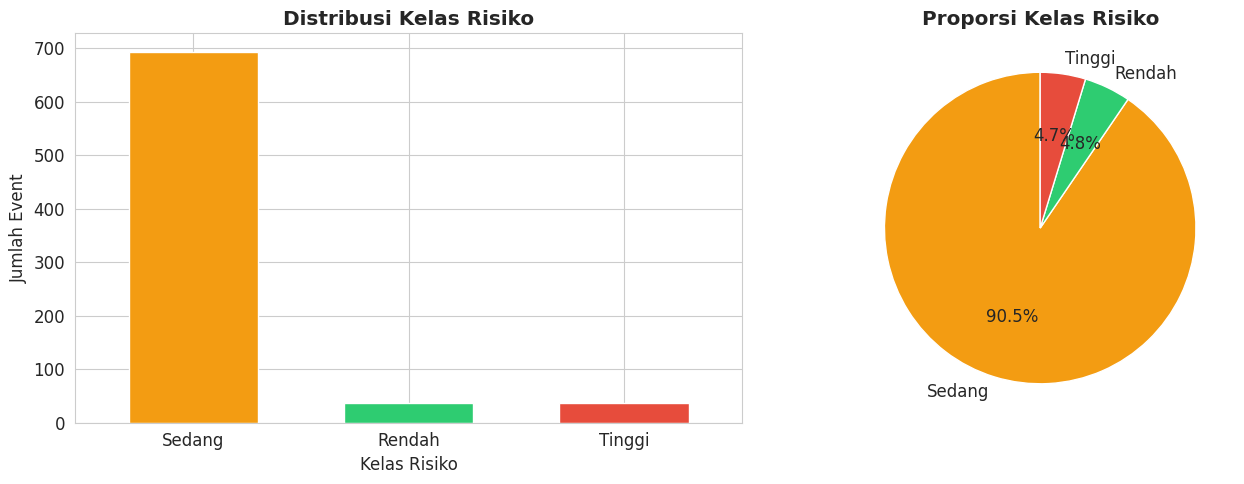

In [ ]:
# ── Fungsi Pelabelan Risiko ───────────────────────────────────────────────────
def label_risiko(row):
    mag   = row['mag']
    depth = row['depth']

    # Kelas Tinggi: Magnitudo besar DAN dangkal
    if mag > 5.0 and depth < 60:
        return 2  # Tinggi
    # Kelas Sedang: Magnitudo menengah
    elif 3.0 <= mag <= 5.0:
        return 1  # Sedang
    # Kelas Rendah: Magnitudo kecil ATAU dalam
    else:
        return 0  # Rendah

df_lembang['risk_label'] = df_lembang.apply(label_risiko, axis=1)
df_lembang['risk_name']  = df_lembang['risk_label'].map({
    0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'
})

# Distribusi kelas
print('DISTRIBUSI KELAS RISIKO:')
print('='*35)
dist = df_lembang['risk_name'].value_counts()
for name, count in dist.items():
    pct = count / len(df_lembang) * 100
    bar = '█' * int(pct / 2)
    print(f'  {name:8s}: {count:5,} ({pct:5.1f}%) {bar}')

# Plot distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Rendah': '#2ecc71', 'Sedang': '#f39c12', 'Tinggi': '#e74c3c'}
dist.plot(kind='bar', ax=axes[0],
          color=[colors[c] for c in dist.index],
          edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Kelas Risiko', fontweight='bold')
axes[0].set_xlabel('Kelas Risiko')
axes[0].set_ylabel('Jumlah Event')
axes[0].tick_params(rotation=0)

dist.plot(kind='pie', ax=axes[1],
          colors=[colors[c] for c in dist.index],
          autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kelas Risiko', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 — Normalisasi Min-Max Scaling

> Sesuai rumus **Persamaan II-10** dan **III-1** di proposal:
> $$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

In [ ]:
# ── Fitur Input (X) dan Label (y) ────────────────────────────────────────────
FITUR = ['mag', 'depth', 'latitude', 'longitude']

X = df_lembang[FITUR].values
y = df_lembang['risk_label'].values

print(f'Shape X (fitur): {X.shape}')
print(f'Shape y (label): {y.shape}')
print(f'Kelas unik     : {np.unique(y)} → 0=Rendah, 1=Sedang, 2=Tinggi')

# Normalisasi
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Verifikasi
print('\nSEBELUM Normalisasi (min/max per fitur):')
for i, f in enumerate(FITUR):
    print(f'  {f:12s}: min={X[:,i].min():.3f}, max={X[:,i].max():.3f}')

print('\nSESUDAH Normalisasi (min/max per fitur):')
for i, f in enumerate(FITUR):
    print(f'  {f:12s}: min={X_scaled[:,i].min():.3f}, max={X_scaled[:,i].max():.3f}')

print('\n✅ Normalisasi berhasil! Semua nilai sekarang dalam range [0, 1]')

Shape X (fitur): (766, 4)
Shape y (label): (766,)
Kelas unik     : [0 1 2] → 0=Rendah, 1=Sedang, 2=Tinggi

SEBELUM Normalisasi (min/max per fitur):
  mag         : min=3.400, max=7.500
  depth       : min=1.410, max=407.300
  latitude    : min=-7.999, max=-5.561
  longitude   : min=106.001, max=109.000

SESUDAH Normalisasi (min/max per fitur):
  mag         : min=0.000, max=1.000
  depth       : min=0.000, max=1.000
  latitude    : min=0.000, max=1.000
  longitude   : min=0.000, max=1.000

✅ Normalisasi berhasil! Semua nilai sekarang dalam range [0, 1]


---
## ✂️ FASE 4 — Pembagian Data (80:20)

> Sesuai **Bab III.3.3** di proposal: rasio 80% data latih dan 20% data uji

In [ ]:
# ── CEK distribusi kelas sebelum split ───────────────────────────────────────
print('Distribusi kelas SEBELUM split:')
unique, counts = np.unique(y, return_counts=True)
label_map = {0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'}
for u, c in zip(unique, counts):
    print(f'  {label_map[u]:8s}: {c:,} data')

# Cek kelas yang terlalu sedikit
min_count = min(counts)
print(f'\nKelas paling sedikit: {min_count} data')

# ── Split adaptif ────────────────────────────────────────────────────────────
if min_count >= 2:
    # Kalau semua kelas >= 2, bisa pakai stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size    = 0.20,
        random_state = 42,
        stratify     = y
    )
    print('\n✅ Split dengan stratify berhasil.')
else:
    # Ada kelas yang cuma 1 data → hapus stratify
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size    = 0.20,
        random_state = 42
        # stratify dihapus karena ada kelas dengan 1 data
    )
    print('\n⚠️  Stratify dinonaktifkan (ada kelas < 2 data). Split tetap 80:20.')

print()
print('PEMBAGIAN DATA:')
print('='*40)
print(f'  Total data : {len(X_scaled):,}')
print(f'  Data Latih : {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  Data Uji   : {len(X_test):,} ({len(X_test)/len(X_scaled)*100:.0f}%)')
print()
print('Distribusi kelas pada data latih:')
for kelas in [0, 1, 2]:
    print(f'  {label_map[kelas]}: {(y_train == kelas).sum():,}')
print()
print('Distribusi kelas pada data uji:')
for kelas in [0, 1, 2]:
    print(f'  {label_map[kelas]}: {(y_test == kelas).sum():,}')

Distribusi kelas SEBELUM split:
  Rendah  : 37 data
  Sedang  : 693 data
  Tinggi  : 36 data

Kelas paling sedikit: 36 data

✅ Split dengan stratify berhasil.

PEMBAGIAN DATA:
  Total data : 766
  Data Latih : 612 (80%)
  Data Uji   : 154 (20%)

Distribusi kelas pada data latih:
  Rendah: 29
  Sedang: 554
  Tinggi: 29

Distribusi kelas pada data uji:
  Rendah: 8
  Sedang: 139
  Tinggi: 7


---
## 🤖 FASE 5 — Training Model SVM (Kernel RBF)

> Sesuai **Bab II.1.3** dan **III.2.3** di proposal:
> - Kernel: **RBF (Radial Basis Function)**
> - Parameter: **C** (regularisasi) dan **γ/Gamma** (lebar kernel)
> - `class_weight='balanced'` untuk menangani **Data Imbalance** (Bab II.7)

In [ ]:
# ── Training Model SVM dengan parameter awal ──────────────────────────────────
svm_model = SVC(
    kernel       = 'rbf',          # Kernel RBF sesuai proposal
    C            = 1.0,            # Parameter regularisasi (akan di-tuning)
    gamma        = 'scale',        # Parameter gamma (akan di-tuning)
    class_weight = 'balanced',     # Menangani data imbalance (Bab II.7)
    random_state = 42,
    probability  = True            # Untuk output probabilitas
)

print('⏳ Melatih model SVM...', end=' ')
svm_model.fit(X_train, y_train)
print('✅ Selesai!')

# Prediksi
y_pred = svm_model.predict(X_test)

print(f'\nJumlah Support Vectors per kelas:')
for i, kelas in enumerate(['Rendah', 'Sedang', 'Tinggi']):
    print(f'  {kelas}: {svm_model.n_support_[i]}')

⏳ Melatih model SVM... ✅ Selesai!

Jumlah Support Vectors per kelas:
  Rendah: 17
  Sedang: 155
  Tinggi: 17


---
## 📊 FASE 6 — Evaluasi Model

> Menggunakan metrik dari **Tabel II-6** di proposal:
> Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix

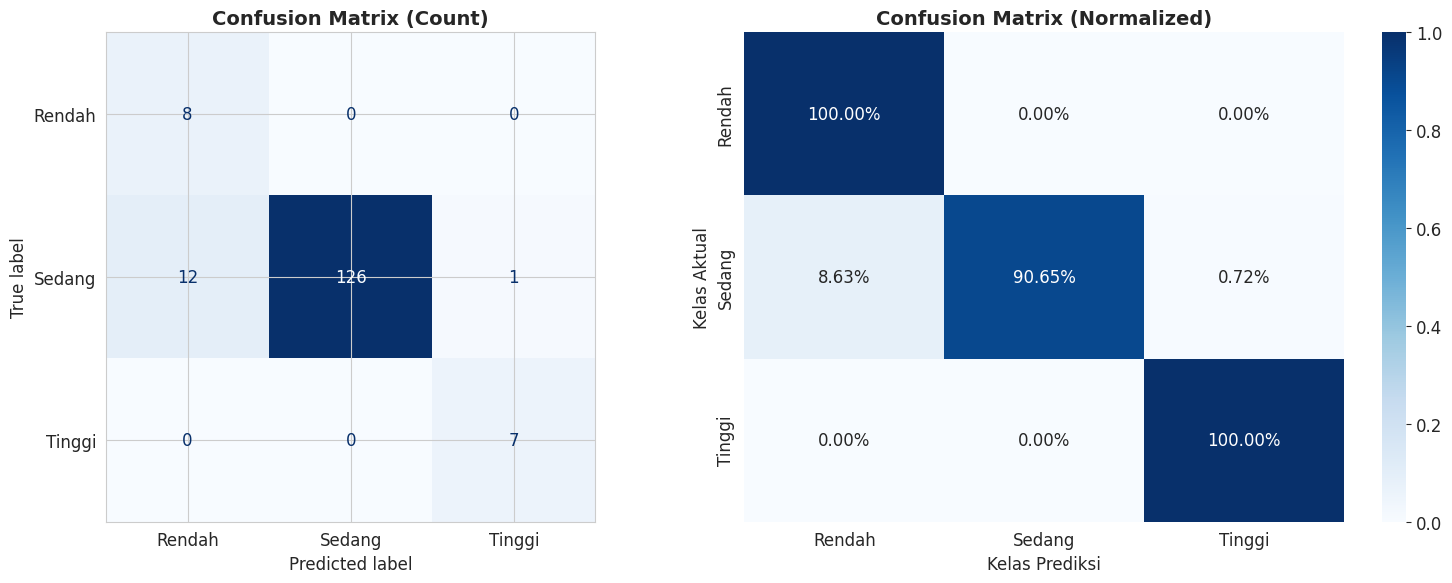

In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
label_names = ['Rendah (0)', 'Sedang (1)', 'Tinggi (2)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix — Raw Count
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Rendah', 'Sedang', 'Tinggi'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Count)', fontweight='bold', fontsize=14)

# Confusion Matrix — Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Rendah', 'Sedang', 'Tinggi'],
            yticklabels=['Rendah', 'Sedang', 'Tinggi'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Kelas Aktual')
axes[1].set_xlabel('Kelas Prediksi')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Metrik Evaluasi Lengkap ───────────────────────────────────────────────────
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('='*55)
print('  HASIL EVALUASI MODEL SVM (Kernel RBF) — DATA UJI')
print('='*55)
print(f'  ✅ Akurasi (Accuracy)  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  ✅ Presisi (Precision) : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  ✅ Recall (Sensitivitas): {rec:.4f}  ({rec*100:.2f}%)')
print(f'  ✅ F1-Score             : {f1:.4f}  ({f1*100:.2f}%)')
print('='*55)
print()
print('CLASSIFICATION REPORT (Per Kelas):')
print(classification_report(y_test, y_pred,
                             target_names=['Rendah', 'Sedang', 'Tinggi']))

  HASIL EVALUASI MODEL SVM (Kernel RBF) — DATA UJI
  ✅ Akurasi (Accuracy)  : 0.9156  (91.56%)
  ✅ Presisi (Precision) : 0.9631  (96.31%)
  ✅ Recall (Sensitivitas): 0.9156  (91.56%)
  ✅ F1-Score             : 0.9304  (93.04%)

CLASSIFICATION REPORT (Per Kelas):
              precision    recall  f1-score   support

      Rendah       0.40      1.00      0.57         8
      Sedang       1.00      0.91      0.95       139
      Tinggi       0.88      1.00      0.93         7

    accuracy                           0.92       154
   macro avg       0.76      0.97      0.82       154
weighted avg       0.96      0.92      0.93       154



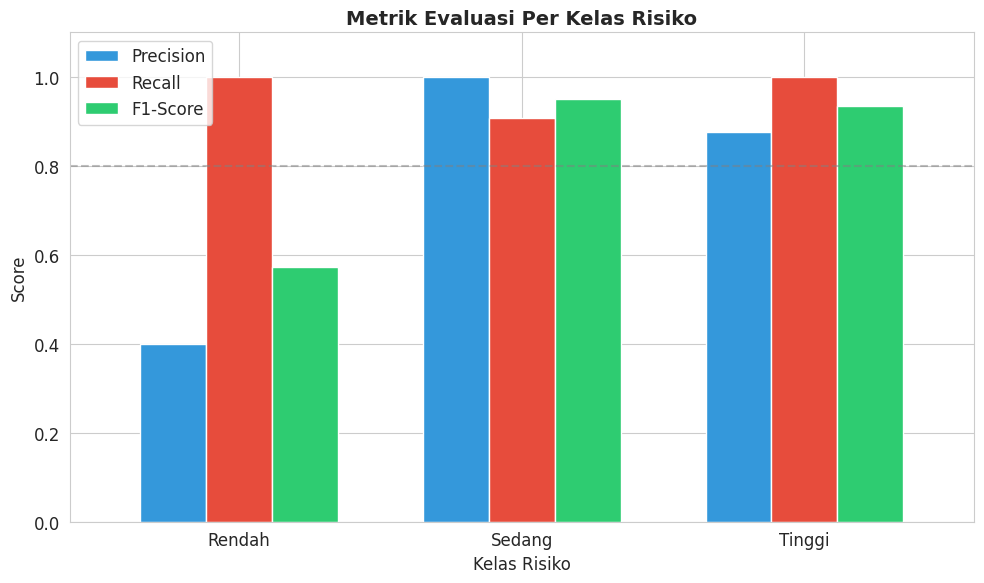

In [ ]:
# ── Visualisasi Metrik Per Kelas ──────────────────────────────────────────────
from sklearn.metrics import classification_report
import json

report = classification_report(y_test, y_pred,
                                target_names=['Rendah', 'Sedang', 'Tinggi'],
                                output_dict=True)

metrics_df = pd.DataFrame(report).T.iloc[:3][['precision', 'recall', 'f1-score']]
metrics_df.index = ['Rendah', 'Sedang', 'Tinggi']

metrics_df.plot(kind='bar', figsize=(10, 6),
                color=['#3498db', '#e74c3c', '#2ecc71'],
                edgecolor='white', width=0.7)
plt.title('Metrik Evaluasi Per Kelas Risiko', fontweight='bold', fontsize=14)
plt.ylabel('Score')
plt.xlabel('Kelas Risiko')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(['Precision', 'Recall', 'F1-Score'])
plt.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.8')
plt.tight_layout()
plt.savefig('metrik_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔄 FASE 7 — K-Fold Cross Validation

> Sesuai **Bab III.4.1** di proposal:
> Dataset dibagi K bagian, proses diulang K kali untuk hasil yang objektif

In [ ]:
# ── K-Fold Cross Validation (K=5 dan K=10) ───────────────────────────────────
kfold_model = SVC(
    kernel       = 'rbf',
    C            = 1.0,
    gamma        = 'scale',
    class_weight = 'balanced',
    random_state = 42
)

hasil_kfold = {}
for k in [5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    scores_acc = cross_val_score(kfold_model, X_scaled, y, cv=skf, scoring='accuracy')
    scores_f1  = cross_val_score(kfold_model, X_scaled, y, cv=skf, scoring='f1_weighted')
    scores_rec = cross_val_score(kfold_model, X_scaled, y, cv=skf, scoring='recall_weighted')

    hasil_kfold[k] = {
        'accuracy': scores_acc,
        'f1'      : scores_f1,
        'recall'  : scores_rec
    }

    print(f'{'='*50}')
    print(f'  HASIL {k}-FOLD CROSS VALIDATION')
    print(f'{'='*50}')
    print(f'  Accuracy: {scores_acc.mean():.4f} ± {scores_acc.std():.4f}')
    print(f'  F1-Score: {scores_f1.mean():.4f} ± {scores_f1.std():.4f}')
    print(f'  Recall  : {scores_rec.mean():.4f} ± {scores_rec.std():.4f}')
    print(f'  Per-fold accuracy: {[f"{s:.3f}" for s in scores_acc]}')
    print()

  HASIL 5-FOLD CROSS VALIDATION
  Accuracy: 0.9334 ± 0.0232
  F1-Score: 0.9412 ± 0.0197
  Recall  : 0.9334 ± 0.0232
  Per-fold accuracy: ['0.968', '0.935', '0.948', '0.902', '0.915']

  HASIL 10-FOLD CROSS VALIDATION
  Accuracy: 0.9359 ± 0.0298
  F1-Score: 0.9449 ± 0.0237
  Recall  : 0.9359 ± 0.0298
  Per-fold accuracy: ['0.987', '0.961', '0.922', '0.961', '0.935', '0.948', '0.882', '0.934', '0.895', '0.934']



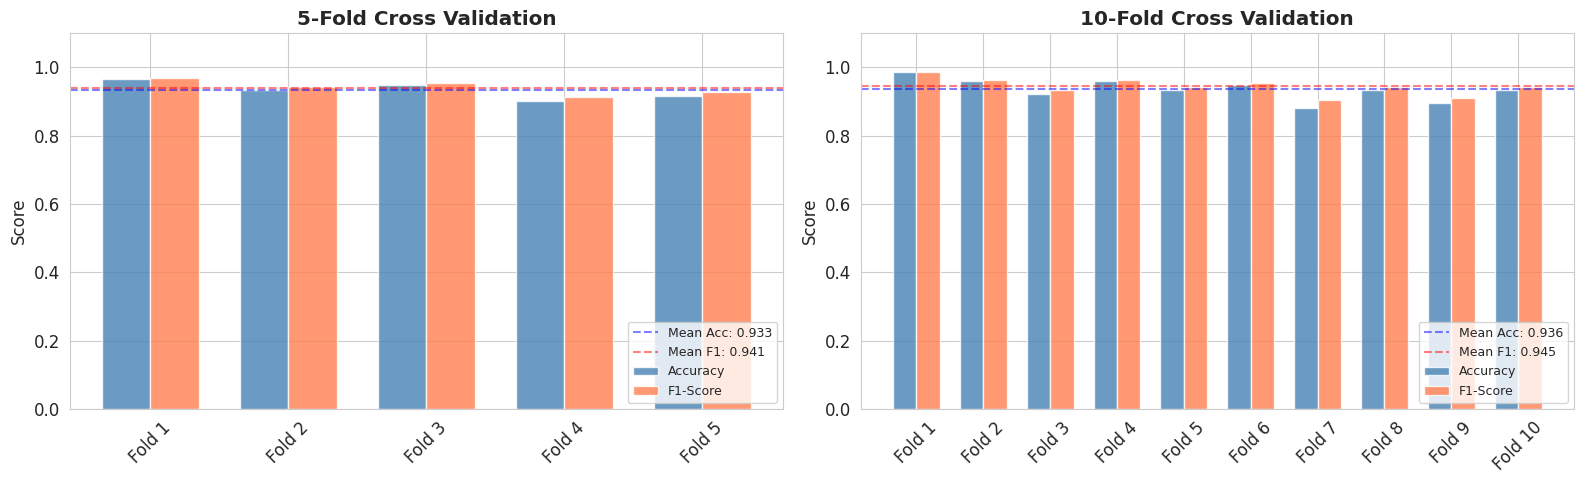

In [ ]:
# Plot performa per fold
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, k in enumerate([5, 10]):
    ax = axes[idx]
    acc_scores = hasil_kfold[k]['accuracy']
    f1_scores  = hasil_kfold[k]['f1']

    folds = [f'Fold {i+1}' for i in range(k)]
    x = np.arange(k)
    width = 0.35

    ax.bar(x - width/2, acc_scores, width, label='Accuracy', color='steelblue', alpha=0.8)
    ax.bar(x + width/2, f1_scores,  width, label='F1-Score',  color='coral',     alpha=0.8)
    ax.axhline(y=acc_scores.mean(), color='blue',   linestyle='--', alpha=0.5,
               label=f'Mean Acc: {acc_scores.mean():.3f}')
    ax.axhline(y=f1_scores.mean(),  color='red',    linestyle='--', alpha=0.5,
               label=f'Mean F1: {f1_scores.mean():.3f}')

    ax.set_title(f'{k}-Fold Cross Validation', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(folds, rotation=45)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('kfold_validation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ FASE 8 — Hyperparameter Tuning (C & Gamma)

> Sesuai **Bab III.2.3** di proposal:
> Optimasi parameter **C** dan **Gamma (γ)** untuk performa terbaik

In [ ]:
# ── Grid Search untuk C dan Gamma ────────────────────────────────────────────
# ⚠️ Proses ini bisa memakan waktu 5-30 menit tergantung ukuran data

param_grid = {
    'C'    : [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale'],
}

svm_tuning = SVC(
    kernel       = 'rbf',
    class_weight = 'balanced',
    random_state = 42
)

grid_search = GridSearchCV(
    estimator = svm_tuning,
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'f1_weighted',   # Prioritas F1 untuk data imbalanced
    n_jobs     = -1,              # Gunakan semua CPU
    verbose    = 1
)

print('⏳ Melakukan Grid Search Hyperparameter Tuning...')
print('   (Proses ini mungkin memakan waktu beberapa menit)\n')
grid_search.fit(X_train, y_train)

print(f'\n✅ Grid Search selesai!')
print(f'   Best Parameters : {grid_search.best_params_}')
print(f'   Best F1-Score   : {grid_search.best_score_:.4f}')

⏳ Melakukan Grid Search Hyperparameter Tuning...
   (Proses ini mungkin memakan waktu beberapa menit)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Grid Search selesai!
   Best Parameters : {'C': 100, 'gamma': 1}
   Best F1-Score   : 0.9892


In [ ]:
# ── Evaluasi Model Terbaik ────────────────────────────────────────────────────
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

acc_best  = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
rec_best  = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
f1_best   = f1_score(y_test, y_pred_best, average='weighted', zero_division=0)

print('='*55)
print('  MODEL SETELAH HYPERPARAMETER TUNING (Best Model)')
print('='*55)
print(f'  Parameter  : C={grid_search.best_params_["C"]}, Gamma={grid_search.best_params_["gamma"]}')
print(f'  ✅ Akurasi  : {acc_best:.4f}  ({acc_best*100:.2f}%)')
print(f'  ✅ Presisi  : {prec_best:.4f}  ({prec_best*100:.2f}%)')
print(f'  ✅ Recall   : {rec_best:.4f}  ({rec_best*100:.2f}%)')
print(f'  ✅ F1-Score : {f1_best:.4f}  ({f1_best*100:.2f}%)')
print('='*55)
print()
print('CLASSIFICATION REPORT (Best Model):')
print(classification_report(y_test, y_pred_best,
                             target_names=['Rendah', 'Sedang', 'Tinggi']))

  MODEL SETELAH HYPERPARAMETER TUNING (Best Model)
  Parameter  : C=100, Gamma=1
  ✅ Akurasi  : 0.9610  (96.10%)
  ✅ Presisi  : 0.9719  (97.19%)
  ✅ Recall   : 0.9610  (96.10%)
  ✅ F1-Score : 0.9647  (96.47%)

CLASSIFICATION REPORT (Best Model):
              precision    recall  f1-score   support

      Rendah       0.58      0.88      0.70         8
      Sedang       1.00      0.97      0.99       139
      Tinggi       0.86      0.86      0.86         7

    accuracy                           0.96       154
   macro avg       0.81      0.90      0.85       154
weighted avg       0.97      0.96      0.96       154



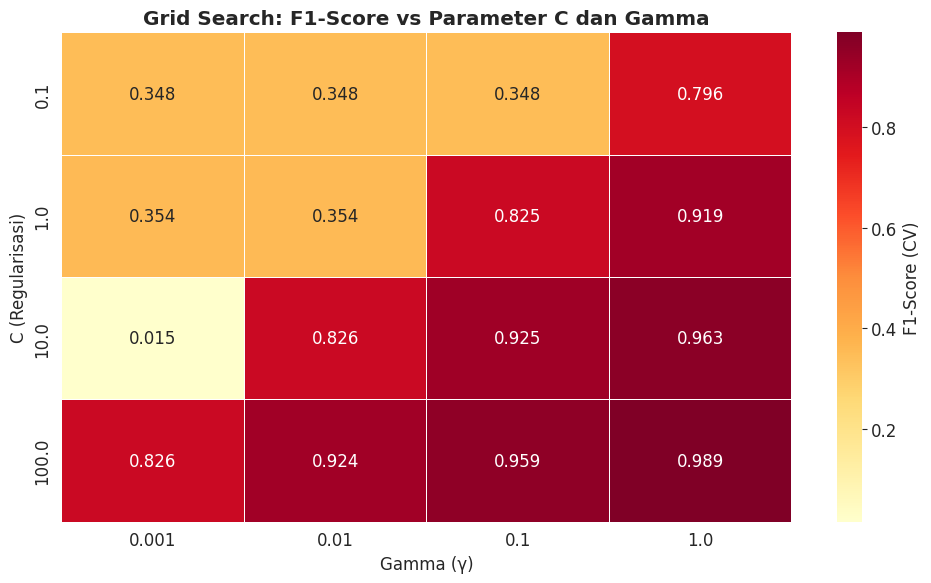

In [ ]:
# ── Visualisasi Heatmap Grid Search ──────────────────────────────────────────
# Filter hasil grid search untuk gamma numerik saja
results = pd.DataFrame(grid_search.cv_results_)
results_filtered = results[results['param_gamma'] != 'scale'].copy()
results_filtered['param_gamma'] = results_filtered['param_gamma'].astype(float)

pivot = results_filtered.pivot_table(
    index   = 'param_C',
    columns = 'param_gamma',
    values  = 'mean_test_score'
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'F1-Score (CV)'})
plt.title('Grid Search: F1-Score vs Parameter C dan Gamma', fontweight='bold')
plt.xlabel('Gamma (γ)')
plt.ylabel('C (Regularisasi)')
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🗺️ FASE 9 — Visualisasi Hasil & Peta Risiko

In [ ]:
# ── Prediksi Seluruh Data untuk Peta ─────────────────────────────────────────
df_lembang['pred_label'] = best_model.predict(X_scaled)
df_lembang['pred_name']  = df_lembang['pred_label'].map({
    0: 'Rendah', 1: 'Sedang', 2: 'Tinggi'
})

# ── Scatter Plot Spasial Hasil Klasifikasi ────────────────────────────────────
fig = px.scatter(
    df_lembang,
    x     = 'longitude',
    y     = 'latitude',
    color = 'pred_name',
    size  = 'mag',
    hover_data = ['mag', 'depth', 'time'],
    color_discrete_map = {
        'Rendah': '#27ae60',
        'Sedang': '#f39c12',
        'Tinggi': '#e74c3c'
    },
    title  = 'Klasifikasi Risiko Seismik — Kawasan Sesar Lembang',
    labels = {
        'longitude': 'Bujur (°E)',
        'latitude' : 'Lintang (°S)',
        'pred_name': 'Kelas Risiko'
    },
    opacity = 0.7,
    width   = 900,
    height  = 600
)
fig.update_layout(legend_title='Kelas Risiko')
fig.show()
fig.write_html('peta_risiko_interaktif.html')
print('✅ Peta interaktif tersimpan sebagai peta_risiko_interaktif.html')

✅ Peta interaktif tersimpan sebagai peta_risiko_interaktif.html


In [ ]:
# ── Peta Folium (Interaktif di Peta Asli) ────────────────────────────────────
color_map = {'Rendah': 'green', 'Sedang': 'orange', 'Tinggi': 'red'}

m = folium.Map(
    location=[-6.75, 107.60],
    zoom_start=10,
    tiles='OpenStreetMap'
)

# Sample 1000 titik agar tidak terlalu berat
sample = df_lembang.sample(min(1000, len(df_lembang)), random_state=42)

for _, row in sample.iterrows():
    folium.CircleMarker(
        location = [row['latitude'], row['longitude']],
        radius   = max(3, row['mag'] * 1.5),
        color    = color_map[row['pred_name']],
        fill     = True,
        fill_opacity = 0.6,
        popup    = folium.Popup(
            f"<b>Risiko: {row['pred_name']}</b><br>"
            f"Magnitudo: {row['mag']:.1f}<br>"
            f"Kedalaman: {row['depth']:.1f} km<br>"
            f"Waktu: {row['time']}",
            max_width=200
        )
    ).add_to(m)

# Tambahkan garis Sesar Lembang
sesar_coords = [
    [-6.758, 107.408], [-6.748, 107.500],
    [-6.738, 107.600], [-6.750, 107.700],
    [-6.760, 107.760]
]
folium.PolyLine(sesar_coords, color='blue', weight=3,
                tooltip='Sesar Lembang').add_to(m)

m.save('peta_folium_sesar_lembang.html')
print('✅ Peta Folium tersimpan!')
display(m)

✅ Peta Folium tersimpan!


---
## 📋 FASE 10 — Ringkasan Hasil & Export

In [ ]:
# ── Tabel Ringkasan Hasil ─────────────────────────────────────────────────────
summary = {
    'Parameter'   : ['Model', 'Kernel', 'C (Best)', 'Gamma (Best)', 'Akurasi',
                      'Presisi', 'Recall', 'F1-Score', 'Total Data', 'Data Latih',
                      'Data Uji', 'K-Fold (5) Acc', 'K-Fold (10) Acc'],
    'Nilai'       : [
        'Support Vector Machine (SVM)',
        'Radial Basis Function (RBF)',
        str(grid_search.best_params_['C']),
        str(grid_search.best_params_['gamma']),
        f'{acc_best:.4f} ({acc_best*100:.2f}%)',
        f'{prec_best:.4f} ({prec_best*100:.2f}%)',
        f'{rec_best:.4f} ({rec_best*100:.2f}%)',
        f'{f1_best:.4f} ({f1_best*100:.2f}%)',
        str(len(df_lembang)),
        str(len(X_train)),
        str(len(X_test)),
        f'{hasil_kfold[5]["accuracy"].mean():.4f} ± {hasil_kfold[5]["accuracy"].std():.4f}',
        f'{hasil_kfold[10]["accuracy"].mean():.4f} ± {hasil_kfold[10]["accuracy"].std():.4f}',
    ]
}

df_summary = pd.DataFrame(summary)
print('='*65)
print('  RINGKASAN HASIL PENELITIAN — SVM SESAR LEMBANG')
print('='*65)
print(df_summary.to_string(index=False))
print('='*65)

# Export summary
df_summary.to_csv('ringkasan_hasil.csv', index=False)

# Export data dengan prediksi
df_lembang.to_csv('data_lembang_dengan_prediksi.csv', index=False)

print('\n✅ File tersimpan:')
print('   - ringkasan_hasil.csv')
print('   - data_lembang_dengan_prediksi.csv')
print('   - confusion_matrix.png')
print('   - metrik_per_kelas.png')
print('   - kfold_validation.png')
print('   - gridsearch_heatmap.png')
print('   - peta_risiko_interaktif.html')
print('   - peta_folium_sesar_lembang.html')

  RINGKASAN HASIL PENELITIAN — SVM SESAR LEMBANG
      Parameter                        Nilai
          Model Support Vector Machine (SVM)
         Kernel  Radial Basis Function (RBF)
       C (Best)                          100
   Gamma (Best)                            1
        Akurasi              0.9610 (96.10%)
        Presisi              0.9719 (97.19%)
         Recall              0.9610 (96.10%)
       F1-Score              0.9647 (96.47%)
     Total Data                          766
     Data Latih                          612
       Data Uji                          154
 K-Fold (5) Acc              0.9334 ± 0.0232
K-Fold (10) Acc              0.9359 ± 0.0298

✅ File tersimpan:
   - ringkasan_hasil.csv
   - data_lembang_dengan_prediksi.csv
   - confusion_matrix.png
   - metrik_per_kelas.png
   - kfold_validation.png
   - gridsearch_heatmap.png
   - peta_risiko_interaktif.html
   - peta_folium_sesar_lembang.html


In [ ]:
# ── Download semua file ke komputer ──────────────────────────────────────────
from google.colab import files
import os

output_files = [
    'ringkasan_hasil.csv',
    'data_lembang_dengan_prediksi.csv',
    'confusion_matrix.png',
    'metrik_per_kelas.png',
    'kfold_validation.png',
    'gridsearch_heatmap.png',
    'peta_risiko_interaktif.html',
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'✅ Download: {f}')
    else:
        print(f'⚠️  File tidak ditemukan: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download: ringkasan_hasil.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Download: gridsearch_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download: peta_risiko_interaktif.html


---
## 📌 Catatan Penting

### Urutan yang Harus Dijalankan:
1. **FASE 1** — Wajib dijalankan pertama kali (install & import)
2. **FASE 2** — Pilih **salah satu** Opsi (A, B, atau C) untuk load data
3. **FASE 3 s/d 10** — Jalankan secara berurutan dari atas ke bawah

### Tips:
- Jika data terlalu sedikit (<100 baris), perluas koordinat bounding box di Fase 3.1
- Jika kelas `Tinggi` sangat sedikit, sesuaikan threshold di fungsi `label_risiko()`
- Grid Search di Fase 8 bisa lama — gunakan **Runtime > Change runtime type > GPU** untuk mempercepat
- Simpan notebook ke Google Drive agar tidak hilang saat session berakhir

### Referensi ke Proposal:
| Fase Notebook | Bab Proposal |
|---|---|
| Pelabelan Risiko | Tabel III-2, Hal. 45 |
| Normalisasi Min-Max | Persamaan II-10, III-1 |
| SVM Kernel RBF | Bab II.1.2, II.1.3 |
| Confusion Matrix | Bab II.4, III.4.2 |
| K-Fold CV | Bab III.4.1 |
| Hyperparameter Tuning | Bab III.2.3 |
| Data Imbalance (class_weight) | Bab II.7 |

In [1]:
import joblib

# Ganti 'model' dengan nama variabel model SVM terbaik kamu,
# (misalnya: best_svm, grid_search.best_estimator_, atau model_svm)
joblib.dump(model, 'usgs_model.pkl')

from google.colab import files
files.download('usgs_model.pkl')

NameError: name 'model' is not defined